# Assignment 8 — Full Fine-Tuning vs. Manual LoRA on a Vision Transformer

This notebook is written for someone who has **never done this before**. Every section
starts with a plain-English explanation of *what* we're about to do and *why*, before
showing the code. You can read it top to bottom like a tutorial, or skip straight to the
code cells if you already understand a section.

## What this assignment is actually asking you to do

You're given a pretrained image classifier called a **Vision Transformer (ViT)**. It was
trained on ImageNet (1000 everyday object classes like "cat", "car", "toaster"). You need
to repurpose it to classify **satellite photos of land** into 10 categories instead
(forest, river, highway, etc.) — a completely different task. This is called
**transfer learning**.

There are two ways to adapt the model, and the assignment wants you to compare them:

1. **Full fine-tuning** — unlock *every single weight* in the model and let training
   update all of them. This usually gives the best accuracy but is slow, uses a lot of
   GPU memory, and produces a huge file to save (~330 MB for ViT-base).
2. **LoRA (Low-Rank Adaptation)** — freeze almost the entire model and only train a
   tiny number of new, small "patch" matrices inserted into a few layers. This trains
   far fewer parameters (often <1% of the model), uses much less memory, and produces a
   tiny file to save — while often getting *close to* full fine-tuning accuracy.

You must implement LoRA **by hand** (no `peft` library) so you understand exactly what it
does mathematically.

## What we will measure for every experiment

For full fine-tuning and for every LoRA configuration, we'll record the same set of
numbers so they can be compared fairly in a table at the end:

| Metric | What it tells you |
|---|---|
| Trainable parameters | How many numbers actually get updated during training |
| Training loss curve | How well the model is fitting the training data over time |
| Validation loss curve | How well it generalizes to unseen data over time |
| Accuracy | % of validation images classified correctly |
| Macro F1-score | Accuracy that also accounts for class imbalance |
| Peak GPU memory | How much GPU RAM was needed |
| Training time | Wall-clock seconds to train |
| Model size on disk | Size of the file you'd need to save/share |

## Notebook roadmap

1. Setup & GPU check
2. Download and explore the EuroSAT RGB dataset
3. Build a PyTorch dataset / dataloaders
4. Load the pretrained ViT
5. Metric & training utilities (shared by every experiment)
6. Experiment A — Full fine-tuning
7. LoRA, explained from scratch, and implemented as a PyTorch module
8. Experiment B — LoRA at rank 16 / 32 / 64 (Query & Value, last 3 blocks)
9. Experiment C — LoRA with different target layers (bonus, addresses the
   "different target layers" objective from the brief)
10. Final comparison table & plots
11. How to turn this into your report

> **Kaggle setup reminder before you run anything:** open the notebook settings panel
> (top right, "..." menu or the side panel) and turn **Internet: On** (needed to download
> the dataset) and **Accelerator: GPU** (T4 x2 or P100 — anything with CUDA). Without a
> GPU this notebook will still run but will be extremely slow.


## 1. Setup

We install/upgrade a few libraries. Kaggle's base image already has PyTorch, but we
pin/upgrade `transformers` (the library that gives us the pretrained ViT) and a couple of
small helpers.

- `transformers` — loads the pretrained ViT model and its image preprocessor
- `scikit-learn` — gives us `accuracy_score` and `f1_score` for evaluation
- `tqdm` — progress bars so you can see training happening live


In [1]:
!pip install -q --upgrade transformers accelerate scikit-learn tqdm
print("Done installing.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 103.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 112.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 97.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0

In [2]:
import os
import io
import math
import time
import zipfile
import random
from pathlib import Path

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

from transformers import ViTForImageClassification, ViTImageProcessor

# Make results reproducible
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("Imports OK. PyTorch version:", torch.__version__)


Imports OK. PyTorch version: 2.10.0+cu128


### GPU check

`torch.cuda.is_available()` tells us whether a GPU is visible to PyTorch. If this prints
`False`, go to the notebook settings and turn the accelerator on — everything below will
still run on CPU, but full fine-tuning a ViT on CPU could take hours per epoch instead of
minutes.


In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU name:", torch.cuda.get_device_name(0))
    print("Total GPU memory: %.1f GB" % (torch.cuda.get_device_properties(0).total_memory / 1024**3))


Using device: cuda
GPU name: Tesla T4
Total GPU memory: 14.6 GB


## 2. Download and explore the EuroSAT RGB dataset

**What is EuroSAT?** It's 27,000 satellite images (64×64 pixels, JPEG) taken by the
Sentinel-2 satellite over Europe, each labelled with one of 10 land-use categories
(AnnualCrop, Forest, HerbaceousVegetation, Highway, Industrial, Pasture, PermanentCrop,
Residential, River, SeaLake). The images are organized in folders — one folder per class,
containing that class's images. This "one folder per class" layout is extremely common and
is exactly what `torchvision.datasets.ImageFolder`-style loading expects.

We download the official RGB-only zip directly from Zenodo (the archive named in the
assignment), then unzip it. This step needs internet access to be enabled in this
notebook's settings.


In [4]:
DATA_ROOT = Path("/kaggle/working/eurosat_data")
ZIP_PATH = DATA_ROOT / "EuroSAT_RGB.zip"
EXTRACT_DIR = DATA_ROOT / "EuroSAT_RGB"
DATA_URL = "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1"

DATA_ROOT.mkdir(parents=True, exist_ok=True)

def download_with_progress(url, dest_path):
    if dest_path.exists():
        print(f"{dest_path.name} already exists, skipping download.")
        return
    resp = requests.get(url, stream=True)
    resp.raise_for_status()
    total = int(resp.headers.get("content-length", 0))
    with open(dest_path, "wb") as f, tqdm(
        total=total, unit="B", unit_scale=True, desc="Downloading EuroSAT_RGB.zip"
    ) as bar:
        for chunk in resp.iter_content(chunk_size=1024 * 1024):
            f.write(chunk)
            bar.update(len(chunk))

download_with_progress(DATA_URL, ZIP_PATH)
print("Download complete. File size: %.1f MB" % (ZIP_PATH.stat().st_size / 1024**2))


Download complete. File size: 90.3 MB


In [5]:
# Unzip only if we haven't already extracted it
if not EXTRACT_DIR.exists():
    print("Extracting...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(DATA_ROOT)
    print("Extraction complete.")
else:
    print("Already extracted.")

# The zip extracts to EuroSAT_RGB/<ClassName>/<image>.jpg
# Find the class folders robustly, in case the folder nesting differs slightly.
candidate_dirs = [p for p in EXTRACT_DIR.iterdir() if p.is_dir()] if EXTRACT_DIR.exists() else []
print("Class folders found:", [d.name for d in candidate_dirs])


Extracting...
Extraction complete.
Class folders found: ['Highway', 'Industrial', 'AnnualCrop', 'Forest', 'HerbaceousVegetation', 'SeaLake', 'River', 'PermanentCrop', 'Pasture', 'Residential']


In [6]:
# Build a flat list of (filepath, class_name) for every image in the dataset
CLASS_NAMES = sorted([d.name for d in EXTRACT_DIR.iterdir() if d.is_dir()])
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {i: name for name, i in CLASS_TO_IDX.items()}

all_files, all_labels = [], []
for class_name in CLASS_NAMES:
    class_dir = EXTRACT_DIR / class_name
    for img_path in class_dir.glob("*.jpg"):
        all_files.append(str(img_path))
        all_labels.append(CLASS_TO_IDX[class_name])

print(f"Total images found: {len(all_files)}")
print(f"Classes ({len(CLASS_NAMES)}): {CLASS_NAMES}")

# Quick sanity check: how many images per class?
counts = pd.Series(all_labels).map(IDX_TO_CLASS).value_counts()
print("\nImages per class:")
print(counts)


Total images found: 27000
Classes (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']

Images per class:
AnnualCrop              3000
Forest                  3000
HerbaceousVegetation    3000
Residential             3000
SeaLake                 3000
Highway                 2500
PermanentCrop           2500
Industrial              2500
River                   2500
Pasture                 2000
Name: count, dtype: int64


Let's actually *look* at a few images, just to build intuition for how different (and
how low-resolution — only 64×64 pixels) satellite imagery looks compared to typical photos.


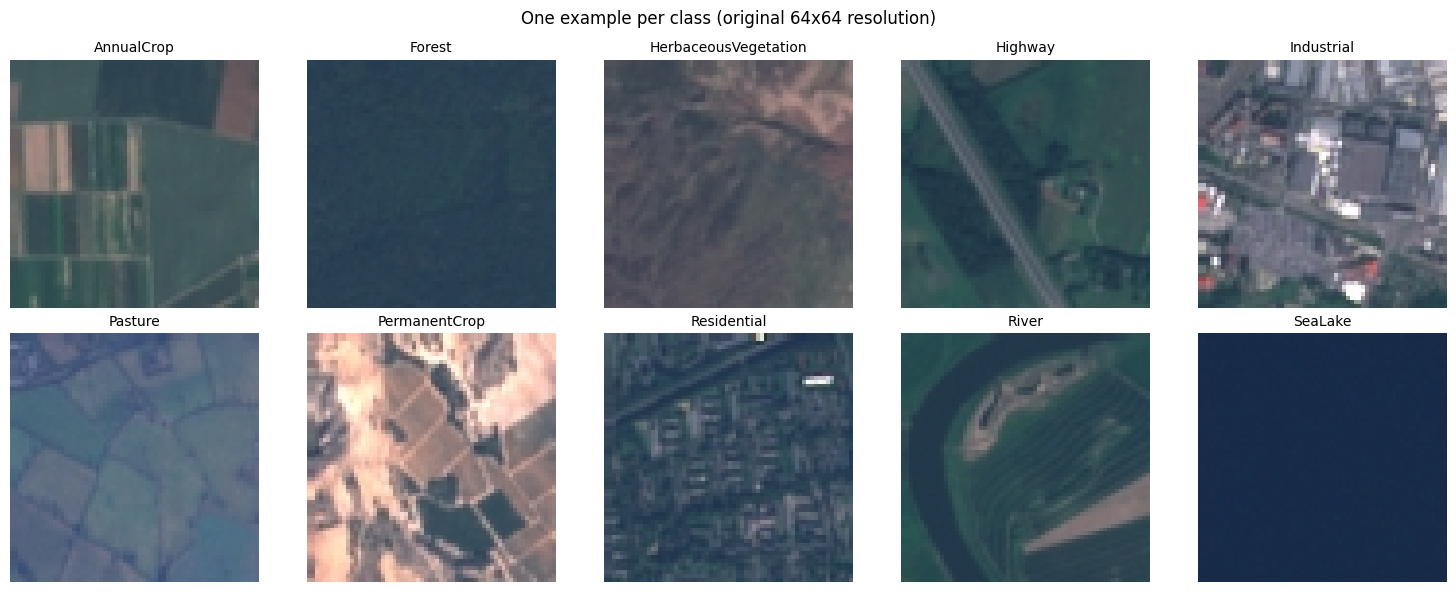

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, class_name in zip(axes.flat, CLASS_NAMES):
    sample_path = next((EXTRACT_DIR / class_name).glob("*.jpg"))
    img = Image.open(sample_path)
    ax.imshow(img)
    ax.set_title(class_name, fontsize=10)
    ax.axis("off")
plt.suptitle("One example per class (original 64x64 resolution)")
plt.tight_layout()
plt.show()


## 3. Building a PyTorch dataset

**Train/validation split.** We hold out 20% of the images as a validation set — the model
never trains on these, so measuring accuracy/F1 on them tells us how well the model
generalizes rather than how well it memorized the training images. We use a **stratified**
split so each class is represented proportionally in both sets.

**Preprocessing.** ViT expects 224×224 images, normalized with specific mean/std values it
was pretrained with. We get those exact numbers from `ViTImageProcessor` so our
preprocessing matches what the pretrained weights expect — using the wrong normalization
is a common bug that silently hurts accuracy.


In [8]:
TRAIN_FILES, VAL_FILES, TRAIN_LABELS, VAL_LABELS = train_test_split(
    all_files, all_labels,
    test_size=0.2,
    random_state=SEED,
    stratify=all_labels,   # keep class proportions equal in train/val
)
print(f"Train images: {len(TRAIN_FILES)}   Val images: {len(VAL_FILES)}")


Train images: 21600   Val images: 5400


In [9]:
MODEL_CHECKPOINT = "google/vit-base-patch16-224"
processor = ViTImageProcessor.from_pretrained(MODEL_CHECKPOINT)

print("Expected image size:", processor.size)
print("Normalization mean:", processor.image_mean)
print("Normalization std:", processor.image_std)


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Expected image size: SizeDict(height=224, width=224, longest_edge=None, shortest_edge=None, max_height=None, max_width=None)
Normalization mean: (0.5, 0.5, 0.5)
Normalization std: (0.5, 0.5, 0.5)


In [10]:
import torchvision.transforms as T

# Build a torchvision transform pipeline using the *exact* numbers the pretrained
# model expects. This is much faster than calling the HuggingFace processor per-image.
IMG_SIZE = processor.size["height"]  # 224
NORMALIZE = T.Normalize(mean=processor.image_mean, std=processor.image_std)

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),   # cheap data augmentation: satellite images have no "up"
    T.RandomVerticalFlip(),     # a rotated field still looks like a field
    T.ToTensor(),
    NORMALIZE,
])

# No augmentation for validation - we want to measure performance on the real images
val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    NORMALIZE,
])


class EuroSATDataset(Dataset):
    '''A minimal PyTorch Dataset: given a list of file paths and labels,
    it loads + preprocesses one image at a time on request.'''

    def __init__(self, file_paths, labels, transform):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        image = Image.open(self.file_paths[idx]).convert("RGB")
        image = self.transform(image)
        label = self.labels[idx]
        return image, label


train_dataset = EuroSATDataset(TRAIN_FILES, TRAIN_LABELS, train_transform)
val_dataset = EuroSATDataset(VAL_FILES, VAL_LABELS, val_transform)
print(f"train_dataset: {len(train_dataset)} items | val_dataset: {len(val_dataset)} items")


train_dataset: 21600 items | val_dataset: 5400 items


In [11]:
# ---- CONFIG: tune these to fit your time budget -----------------------------
CONFIG = {
    "batch_size": 32,
    "epochs_full_ft": 3,      # full fine-tuning epochs
    "epochs_lora": 3,         # LoRA epochs (per rank)
    "epochs_target_layers": 2,# shorter, for the bonus target-layer comparison
    "lr_full_ft": 2e-5,       # full fine-tuning uses a small LR - all weights are sensitive
    "lr_lora": 1e-3,          # LoRA uses a larger LR - the new matrices start at zero
    "lora_ranks": [16, 32, 64],
    "lora_alpha": 32,         # LoRA scaling factor, explained in section 7
    "num_workers": 2,
}
# If you just want to make sure the whole pipeline runs end-to-end quickly before
# committing to a full run, set this below 1.0, e.g. SUBSET_FRACTION = 0.1,
# then set it back to 1.0 for your real results.
SUBSET_FRACTION = 1.0

def make_loaders(subset_fraction=1.0):
    if subset_fraction < 1.0:
        n_train = int(len(train_dataset) * subset_fraction)
        n_val = int(len(val_dataset) * subset_fraction)
        train_idx = np.random.choice(len(train_dataset), n_train, replace=False)
        val_idx = np.random.choice(len(val_dataset), n_val, replace=False)
        train_subset = torch.utils.data.Subset(train_dataset, train_idx)
        val_subset = torch.utils.data.Subset(val_dataset, val_idx)
    else:
        train_subset, val_subset = train_dataset, val_dataset

    train_loader = DataLoader(train_subset, batch_size=CONFIG["batch_size"], shuffle=True,
                               num_workers=CONFIG["num_workers"], pin_memory=True)
    val_loader = DataLoader(val_subset, batch_size=CONFIG["batch_size"], shuffle=False,
                             num_workers=CONFIG["num_workers"], pin_memory=True)
    return train_loader, val_loader

train_loader, val_loader = make_loaders(SUBSET_FRACTION)
print(f"Batches per epoch - train: {len(train_loader)}  val: {len(val_loader)}")


Batches per epoch - train: 675  val: 169


## 4. Loading the pretrained Vision Transformer

**What's inside a ViT, briefly:** the image is cut into fixed-size 16×16 patches, each
patch is flattened and projected into a vector (a "patch embedding"), a learnable
`[CLS]` token is prepended, and the whole sequence is passed through a stack of standard
Transformer encoder blocks (the same self-attention architecture used in language models,
just applied to image patches instead of words). The final representation of the `[CLS]`
token is fed into a classification head (a single linear layer) to produce class scores.

`google/vit-base-patch16-224` was pretrained on ImageNet with a 1000-class head. We load
it with `num_labels=10` and `ignore_mismatched_sizes=True`, which tells HuggingFace
"replace the old 1000-class head with a fresh, randomly-initialized 10-class head" — this
new head is small and always needs to be trained from scratch, in both experiments below.


In [12]:
def load_fresh_model():
    '''Loads a brand-new copy of the pretrained ViT with a fresh 10-class head.
    We call this every time we start a new experiment so experiments never leak
    trained weights into each other.'''
    model = ViTForImageClassification.from_pretrained(
        MODEL_CHECKPOINT,
        num_labels=len(CLASS_NAMES),
        id2label=IDX_TO_CLASS,
        label2id=CLASS_TO_IDX,
        ignore_mismatched_sizes=True,
    )
    return model

_probe_model = load_fresh_model()
n_total = sum(p.numel() for p in _probe_model.parameters())
print(f"Total parameters in ViT-base: {n_total:,}")
del _probe_model


config.json: 0.00B [00:00, ?B/s]

[transformers] You passed `num_labels=10` which is incompatible to the `id2label` map of length `1000`.


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                           
------------------+----------+-------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([10])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Total parameters in ViT-base: 85,806,346


## 5. Shared utilities: training loop, evaluation, and measuring everything

To keep the experiments comparable, we write **one** training function and **one**
evaluation function, and reuse them for every experiment (full fine-tuning and every LoRA
variant). The only thing that changes between experiments is which parameters have
`requires_grad = True`.

A few things worth understanding here:

- **Trainable vs. total parameters.** `requires_grad=True` marks a parameter as
  "unfrozen" — PyTorch will compute gradients for it and the optimizer will update it.
  Everything else is frozen: it still takes part in the forward pass (so information can
  flow through it), but it never changes.
- **GPU memory** is measured with `torch.cuda.max_memory_allocated`, which tracks the
  single highest amount of GPU memory used at any point — this is the number that
  determines whether your setup would fit on a given GPU.
- **Model size on disk** is measured by actually serializing the state dict with
  `torch.save` into an in-memory buffer and checking its byte size. For LoRA we only
  serialize the *trainable* parameters (the tiny adapter + the classification head) —
  that's the whole point of LoRA: you can distribute a few-megabyte adapter file instead
  of the full ~330 MB model.


In [13]:
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def state_dict_size_mb(state_dict):
    buffer = io.BytesIO()
    torch.save(state_dict, buffer)
    return len(buffer.getvalue()) / (1024 ** 2)


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(pixel_values=images).logits
            loss = criterion(logits, labels)
            running_loss += loss.item() * images.size(0)
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    avg_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")
    return avg_loss, acc, f1


def train_experiment(model, train_loader, val_loader, epochs, lr, device, tag):
    '''Trains `model` for `epochs` epochs, evaluating on val_loader after each epoch.
    Only parameters with requires_grad=True are updated. Returns a dict of everything
    the assignment asks us to report.'''
    model.to(device)
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad], lr=lr
    )
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}

    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats(device)
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        pbar = tqdm(train_loader, desc=f"[{tag}] epoch {epoch + 1}/{epochs}")
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(pixel_values=images).logits
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            pbar.set_postfix(loss=loss.item())

        train_loss = running_loss / len(train_loader.dataset)
        val_loss, val_acc, val_f1 = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        print(f"[{tag}] epoch {epoch + 1}: "
              f"train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  "
              f"val_acc={val_acc:.4f}  val_f1={val_f1:.4f}")

    elapsed_seconds = time.time() - start_time
    peak_mem_mb = (torch.cuda.max_memory_allocated(device) / (1024 ** 2)
                   if device.type == "cuda" else float("nan"))

    total_params, trainable_params = count_parameters(model)

    result = {
        "tag": tag,
        "history": history,
        "final_val_acc": history["val_acc"][-1],
        "final_val_f1": history["val_f1"][-1],
        "train_time_sec": elapsed_seconds,
        "peak_gpu_mem_mb": peak_mem_mb,
        "total_params": total_params,
        "trainable_params": trainable_params,
        "trainable_pct": 100 * trainable_params / total_params,
    }
    return result, model


## 6. Experiment A — Full fine-tuning

Every parameter in the model — patch embeddings, all 12 Transformer blocks, and the new
classification head — is unfrozen and updated during training. This is the baseline we'll
compare LoRA against.

We use a small learning rate (`2e-5`), which is standard practice for full fine-tuning of
pretrained Transformers: the pretrained weights already encode a lot of useful knowledge,
and large updates would destroy it ("catastrophic forgetting").


In [14]:
full_ft_model = load_fresh_model()

# Full fine-tuning: leave every parameter trainable (this is already the default,
# spelled out here for clarity)
for p in full_ft_model.parameters():
    p.requires_grad = True

total, trainable = count_parameters(full_ft_model)
print(f"Full fine-tuning -> total params: {total:,} | trainable params: {trainable:,} (100%)")

full_ft_result, full_ft_model = train_experiment(
    full_ft_model, train_loader, val_loader,
    epochs=CONFIG["epochs_full_ft"], lr=CONFIG["lr_full_ft"],
    device=DEVICE, tag="FullFT",
)

full_ft_result["model_size_mb"] = state_dict_size_mb(full_ft_model.state_dict())
print("\nFull fine-tuning summary:", {k: v for k, v in full_ft_result.items() if k != "history"})


[transformers] You passed `num_labels=10` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                           
------------------+----------+-------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([10])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Full fine-tuning -> total params: 85,806,346 | trainable params: 85,806,346 (100%)


[FullFT] epoch 1/3:   0%|          | 0/675 [00:00<?, ?it/s]

[FullFT] epoch 1: train_loss=0.2001  val_loss=0.0668  val_acc=0.9789  val_f1=0.9786


[FullFT] epoch 2/3:   0%|          | 0/675 [00:00<?, ?it/s]

[FullFT] epoch 2: train_loss=0.0458  val_loss=0.0458  val_acc=0.9846  val_f1=0.9843


[FullFT] epoch 3/3:   0%|          | 0/675 [00:00<?, ?it/s]

[FullFT] epoch 3: train_loss=0.0296  val_loss=0.0431  val_acc=0.9856  val_f1=0.9852

Full fine-tuning summary: {'tag': 'FullFT', 'final_val_acc': 0.9855555555555555, 'final_val_f1': 0.9851858256019999, 'train_time_sec': 2506.682424068451, 'peak_gpu_mem_mb': 4694.72216796875, 'total_params': 85806346, 'trainable_params': 85806346, 'trainable_pct': 100.0, 'model_size_mb': 327.39433193206787}


In [15]:
# Free GPU memory before the next experiment - important on Kaggle's limited GPUs
del full_ft_model
torch.cuda.empty_cache()


## 7. LoRA, explained from scratch

### The core idea

Inside every Transformer block, attention uses three learned linear projections of the
input: **Query (Q)**, **Key (K)**, and **Value (V)**. Each is just a matrix multiplication:
`output = x @ W^T + b`, where `W` is a weight matrix of shape
`(out_features, in_features)`.

Full fine-tuning updates `W` directly: `W_new = W_old + ΔW`, where `ΔW` is a full-sized
matrix with exactly as many numbers as `W` itself. For ViT-base, each of these matrices is
768×768 — nearly 590,000 numbers, per projection, per block.

**LoRA's insight:** instead of learning a full-sized `ΔW`, approximate it as the product
of two much smaller matrices:

```
ΔW ≈ B @ A         where A has shape (r, in_features)
                          B has shape (out_features, r)
```

`r` is the **rank** — a small number (16, 32, 64 in this assignment) that controls how
expressive the approximation is. Instead of learning `768 × 768 = 589,824` numbers, we
learn `r × 768 + 768 × r` numbers. At `r=16` that's `768×16 + 16×768 = 24,576` — **about
4% of the original size**. The original weight `W` stays completely frozen; we only ever
train `A` and `B`.

The forward pass becomes:

```
output = x @ W_frozen^T + b_frozen   +   scaling * (x @ A^T @ B^T)
          \_______ original, frozen ______/     \____ new, trainable ____/
```

`scaling = alpha / r`, where `alpha` is a hyperparameter that controls how much influence
the LoRA update has (bigger `alpha` = stronger LoRA contribution for the same rank).

### Why initialize B to all zeros?

`A` is initialized randomly, but `B` is initialized to **all zeros**. Since
`ΔW = B @ A`, if `B` is all zeros then `ΔW = 0` at the very start of training — the model
behaves *exactly* like the original pretrained model on step 1, and then gradually learns
a useful correction. This makes training stable from the first batch.

### Why this saves memory and time

- **Fewer trainable parameters** → the optimizer (AdamW) needs far less memory to store
  its running statistics (it keeps two extra numbers per trainable parameter).
- **Shorter backward pass** → gradients only need to be computed and stored for `A`, `B`,
  and the classification head, not for the frozen weights, which reduces both compute and
  the activation memory PyTorch has to keep around.
- **Tiny checkpoint files** → you only need to save `A`, `B`, and the head — a few
  megabytes instead of ~330 MB.


In [16]:
class LoRALinear(nn.Module):
    '''Wraps an existing nn.Linear layer and adds a trainable low-rank update
    on top of it, while freezing the original layer's weight and bias.

    forward(x) = base_linear(x) + scaling * (x @ A^T @ B^T)
    '''

    def __init__(self, base_linear: nn.Linear, r: int, alpha: int):
        super().__init__()
        assert isinstance(base_linear, nn.Linear)
        self.base_linear = base_linear
        self.in_features = base_linear.in_features
        self.out_features = base_linear.out_features
        self.r = r
        self.alpha = alpha
        self.scaling = alpha / r

        # Freeze the original weight/bias - LoRA never touches these directly
        self.base_linear.weight.requires_grad = False
        if self.base_linear.bias is not None:
            self.base_linear.bias.requires_grad = False

        # The two new, small, trainable matrices
        self.lora_A = nn.Parameter(torch.zeros(r, self.in_features))
        self.lora_B = nn.Parameter(torch.zeros(self.out_features, r))

        # Standard LoRA init: A ~ small random values, B = 0 (see explanation above)
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B)

    def forward(self, x):
        base_out = self.base_linear(x)
        lora_update = (x @ self.lora_A.t()) @ self.lora_B.t()
        return base_out + self.scaling * lora_update

    def extra_repr(self):
        return f"in={self.in_features}, out={self.out_features}, r={self.r}, alpha={self.alpha}"


### Injecting LoRA into specific layers of the ViT

Inside HuggingFace's `ViTForImageClassification`, the path to block `i`'s attention
projections is:

```
model.vit.encoder.layer[i].attention.attention.query   # nn.Linear
model.vit.encoder.layer[i].attention.attention.key     # nn.Linear
model.vit.encoder.layer[i].attention.attention.value   # nn.Linear
model.vit.encoder.layer[i].attention.output.dense      # nn.Linear (attention output projection)
model.vit.encoder.layer[i].intermediate.dense          # nn.Linear (MLP, first layer)
model.vit.encoder.layer[i].output.dense                # nn.Linear (MLP, second layer)
```

ViT-base has 12 blocks total (indices 0–11). "The last three Transformer blocks" means
indices `9, 10, 11`.

The function below replaces the chosen `nn.Linear` layers with our `LoRALinear` wrapper,
in place, inside the loaded model.


In [17]:
def get_vit_layers(model):
    '''Returns the sequence of ViT transformer blocks, regardless of whether the
    installed transformers version nests them under `.encoder.layer` (< 5.0) or
    exposes them directly as `.layers` (>= 5.0).'''
    vit = model.vit
    if hasattr(vit, "encoder") and hasattr(vit.encoder, "layer"):
        return vit.encoder.layer
    if hasattr(vit, "layers"):
        return vit.layers
    raise AttributeError(
        "Could not locate the ViT transformer blocks on this model. "
        "Run `print(model.vit)` to inspect its structure and adjust get_vit_layers()."
    )


def get_projection(layer, proj_name):
    '''Given one transformer block and a logical projection name
    ("query", "key", "value", or "attn_output"), returns (parent_module, attr_name)
    so the caller can getattr/setattr on parent_module - this hides the difference
    between the old nested attention.attention.{query,key,value} + attention.output.dense
    layout and the new flat attention.{q_proj,k_proj,v_proj,o_proj} layout.'''
    attn = layer.attention
    new_names = {"query": "q_proj", "key": "k_proj", "value": "v_proj", "attn_output": "o_proj"}
    if hasattr(attn, new_names[proj_name]):
        return attn, new_names[proj_name]
    if proj_name in ("query", "key", "value"):
        return attn.attention, proj_name
    return attn.output, "dense"  # proj_name == "attn_output", old layout


def apply_lora(model, layer_indices, target_projections, r, alpha):
    '''
    layer_indices: which transformer blocks to modify, e.g. [9, 10, 11]
    target_projections: which projections inside each block's attention to wrap,
                         any subset of {"query", "key", "value"}. (The attention output
                         projection and the MLP layers are left untouched by default -
                         see Experiment C for a version that also wraps those.)
    '''
    layers = get_vit_layers(model)
    for idx in layer_indices:
        layer = layers[idx]
        for proj_name in target_projections:
            parent, attr = get_projection(layer, proj_name)
            original_linear = getattr(parent, attr)
            wrapped = LoRALinear(original_linear, r=r, alpha=alpha)
            setattr(parent, attr, wrapped)
    return model


def freeze_for_lora(model):
    '''Freezes everything except LoRA's A/B matrices and the classification head.
    The classification head is brand-new and randomly initialized (see section 4), so
    it must always be trained - LoRA only concerns itself with adapting existing,
    pretrained weights.'''
    for name, param in model.named_parameters():
        if "lora_" in name or "classifier" in name:
            param.requires_grad = True
        else:
            param.requires_grad = False
    return model


In [18]:
# Quick smoke test: build one LoRA model and print which layers changed
_test_model = load_fresh_model()
_test_model = apply_lora(_test_model, layer_indices=[9, 10, 11],
                          target_projections=["query", "value"], r=16, alpha=CONFIG["lora_alpha"])
_test_model = freeze_for_lora(_test_model)

total, trainable = count_parameters(_test_model)
print(f"Sanity check (r=16, Q+V, last 3 blocks) -> "
      f"total: {total:,} | trainable: {trainable:,} ({100*trainable/total:.3f}%)")
print("\nBlock 11's attention module now looks like:")
print(get_vit_layers(_test_model)[11].attention)

del _test_model
torch.cuda.empty_cache()



[transformers] You passed `num_labels=10` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                           
------------------+----------+-------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([10])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Sanity check (r=16, Q+V, last 3 blocks) -> total: 85,953,802 | trainable: 155,146 (0.180%)

Block 11's attention module now looks like:
ViTAttention(
  (q_proj): LoRALinear(
    in=768, out=768, r=16, alpha=32
    (base_linear): Linear(in_features=768, out_features=768, bias=True)
  )
  (k_proj): Linear(in_features=768, out_features=768, bias=True)
  (v_proj): LoRALinear(
    in=768, out=768, r=16, alpha=32
    (base_linear): Linear(in_features=768, out_features=768, bias=True)
  )
  (o_proj): Linear(in_features=768, out_features=768, bias=True)
)


## 8. Experiment B — LoRA on Query & Value, last 3 blocks, ranks 16 / 32 / 64

This is the assignment's core required experiment. For each rank in `[16, 32, 64]` we:

1. Load a **fresh** pretrained ViT (so no experiment leaks into another)
2. Wrap the Query and Value projections of blocks 9, 10, 11 with `LoRALinear`
3. Freeze everything except the LoRA matrices and the classification head
4. Train and record every metric

We keep `alpha` fixed (`CONFIG["lora_alpha"]`) across ranks so the only thing changing
between runs is the rank itself — this isolates the effect of rank on accuracy /
parameter count / speed, which is exactly what the assignment asks you to study.


In [19]:
lora_rank_results = {}
lora_rank_models = {}

for r in CONFIG["lora_ranks"]:
    print(f"\n{'='*70}\nLoRA rank = {r}\n{'='*70}")
    model = load_fresh_model()
    model = apply_lora(model, layer_indices=[9, 10, 11],
                        target_projections=["query", "value"],
                        r=r, alpha=CONFIG["lora_alpha"])
    model = freeze_for_lora(model)

    total, trainable = count_parameters(model)
    print(f"total params: {total:,} | trainable params: {trainable:,} "
          f"({100*trainable/total:.3f}%)")

    result, model = train_experiment(
        model, train_loader, val_loader,
        epochs=CONFIG["epochs_lora"], lr=CONFIG["lr_lora"],
        device=DEVICE, tag=f"LoRA-r{r}",
    )

    # Only the trainable pieces (LoRA matrices + head) need to be saved to reuse this
    # adapter later - that's the whole storage benefit of LoRA.
    lora_state = {k: v for k, v in model.state_dict().items()
                  if "lora_" in k or "classifier" in k}
    result["model_size_mb"] = state_dict_size_mb(lora_state)

    lora_rank_results[r] = result
    lora_rank_models[r] = model  # kept in case you want to inspect one later

    print(f"\nRank {r} summary:", {k: v for k, v in result.items() if k != "history"})

    del model
    torch.cuda.empty_cache()



LoRA rank = 16


[transformers] You passed `num_labels=10` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                           
------------------+----------+-------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([10])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


total params: 85,953,802 | trainable params: 155,146 (0.180%)


...

[LoRA-r64] epoch 1: train_loss=0.1772  val_loss=0.0955  val_acc=0.9648  val_f1=0.9629


[LoRA-r64] epoch 2/3:   0%|          | 0/675 [00:00<?, ?it/s]

[LoRA-r64] epoch 2: train_loss=0.0694  val_loss=0.1086  val_acc=0.9659  val_f1=0.9642


[LoRA-r64] epoch 3/3:   0%|          | 0/675 [00:00<?, ?it/s]

[LoRA-r64] epoch 3: train_loss=0.0515  val_loss=0.1061  val_acc=0.9661  val_f1=0.9653

Rank 64 summary: {'tag': 'LoRA-r64', 'final_val_acc': 0.9661111111111111, 'final_val_f1': 0.9652584070003016, 'train_time_sec': 1225.142103433609, 'peak_gpu_mem_mb': 1799.9521484375, 'total_params': 86396170, 'trainable_params': 597514, 'trainable_pct': 0.6915977872630233, 'model_size_mb': 2.283989906311035}


## 9. Experiment C — Different LoRA target layers (bonus)

The assignment's objectives list also asks you to understand the effect of **which**
layers LoRA is applied to, not just the rank. Here we hold the rank fixed at 16 (a
reasonable middle value) and vary *where* LoRA is inserted:

- **A — Q+V, last 3 blocks** (the same configuration as the main experiment, rank 16,
  included here again for a direct side-by-side comparison)
- **B — Q+K+V + attention output, last 3 blocks** (more coverage per block)
- **C — Q+V, all 12 blocks** (same projections, but spread across the whole network)

This lets you compare "go deeper in a few blocks" vs. "spread across every block" at a
similar trainable-parameter budget, and see the accuracy/parameter/time trade-off.

We use fewer epochs here (`CONFIG["epochs_target_layers"]`) purely to keep total runtime
reasonable — increase it if you have GPU time to spare.


In [20]:
def apply_lora_full(model, layer_indices, target_projections, r, alpha,
                     include_attn_output=False):
    model = apply_lora(model, layer_indices, target_projections, r, alpha)
    if include_attn_output:
        layers = get_vit_layers(model)
        for idx in layer_indices:
            layer = layers[idx]
            parent, attr = get_projection(layer, "attn_output")
            out_dense = getattr(parent, attr)
            setattr(parent, attr, LoRALinear(out_dense, r=r, alpha=alpha))
    return model


TARGET_LAYER_VARIANTS = {
    "A_QV_last3": dict(layer_indices=[9, 10, 11],
                        target_projections=["query", "value"],
                        include_attn_output=False),
    "B_QKV+Out_last3": dict(layer_indices=[9, 10, 11],
                             target_projections=["query", "key", "value"],
                             include_attn_output=True),
    "C_QV_all12": dict(layer_indices=list(range(12)),
                        target_projections=["query", "value"],
                        include_attn_output=False),
}

target_layer_results = {}

for variant_name, cfg in TARGET_LAYER_VARIANTS.items():
    print(f"\n{'='*70}\nTarget-layer variant: {variant_name}\n{'='*70}")
    model = load_fresh_model()
    model = apply_lora_full(model, r=16, alpha=CONFIG["lora_alpha"], **cfg)
    model = freeze_for_lora(model)

    total, trainable = count_parameters(model)
    print(f"total params: {total:,} | trainable params: {trainable:,} "
          f"({100*trainable/total:.3f}%)")

    result, model = train_experiment(
        model, train_loader, val_loader,
        epochs=CONFIG["epochs_target_layers"], lr=CONFIG["lr_lora"],
        device=DEVICE, tag=variant_name,
    )

    lora_state = {k: v for k, v in model.state_dict().items()
                  if "lora_" in k or "classifier" in k}
    result["model_size_mb"] = state_dict_size_mb(lora_state)

    target_layer_results[variant_name] = result
    print(f"\n{variant_name} summary:", {k: v for k, v in result.items() if k != "history"})

    del model
    torch.cuda.empty_cache()



Target-layer variant: A_QV_last3


[transformers] You passed `num_labels=10` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                           
------------------+----------+-------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([10])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


total params: 85,953,802 | trainable params: 155,146 (0.180%)


...

total params: 86,396,170 | trainable params: 597,514 (0.692%)


[C_QV_all12] epoch 1/2:   0%|          | 0/675 [00:00<?, ?it/s]

[C_QV_all12] epoch 1: train_loss=0.1537  val_loss=0.0756  val_acc=0.9728  val_f1=0.9721


[C_QV_all12] epoch 2/2:   0%|          | 0/675 [00:00<?, ?it/s]

[C_QV_all12] epoch 2: train_loss=0.0630  val_loss=0.0796  val_acc=0.9737  val_f1=0.9731

C_QV_all12 summary: {'tag': 'C_QV_all12', 'final_val_acc': 0.9737037037037037, 'final_val_f1': 0.9731282201666215, 'train_time_sec': 1314.7843873500824, 'peak_gpu_mem_mb': 3964.93505859375, 'total_params': 86396170, 'trainable_params': 597514, 'trainable_pct': 0.6915977872630233, 'model_size_mb': 2.2948122024536133}


## 10. Final comparison

Now we gather every experiment's numbers into one table, plus a couple of plots. This
table is the centerpiece of your report — it directly answers every bullet point in the
assignment's objective list (trainable parameters, loss curves, accuracy, F1, GPU memory,
training time, model size, effect of rank, effect of target layers).


In [21]:
summary_rows = []

def add_row(name, result):
    summary_rows.append({
        "experiment": name,
        "trainable_params": result["trainable_params"],
        "total_params": result["total_params"],
        "trainable_pct": round(result["trainable_pct"], 4),
        "model_size_mb": round(result["model_size_mb"], 2),
        "train_time_sec": round(result["train_time_sec"], 1),
        "peak_gpu_mem_mb": round(result["peak_gpu_mem_mb"], 1),
        "val_accuracy": round(result["final_val_acc"], 4),
        "val_f1_macro": round(result["final_val_f1"], 4),
    })

add_row("Full Fine-Tuning", full_ft_result)
for r, result in lora_rank_results.items():
    add_row(f"LoRA r={r} (Q+V, last 3 blocks)", result)
for name, result in target_layer_results.items():
    add_row(f"LoRA r=16, variant {name}", result)

summary_df = pd.DataFrame(summary_rows)
summary_df


,experiment,trainable_params,total_params,trainable_pct,model_size_mb,train_time_sec,peak_gpu_mem_mb,val_accuracy,val_f1_macro
0,Full Fine-Tuning,85806346,85806346,100.0000,327.39,2506.7,4694.7,0.9856,0.9852
1,"LoRA r=16 (Q+V, last 3 blocks)",155146,85953802,0.1805,0.60,1214.1,1127.5,0.9617,0.9604
2,"LoRA r=32 (Q+V, last 3 blocks)",302602,86101258,0.3514,1.16,1215.9,1460.0,0.9767,0.9757
3,"LoRA r=64 (Q+V, last 3 blocks)",597514,86396170,0.6916,2.28,1225.1,1800.0,0.9661,0.9653
4,"LoRA r=16, variant A_QV_last3",155146,85953802,0.1805,0.60,808.1,2117.4,0.9650,0.9640
5,"LoRA r=16, variant B_QKV+Out_last3",302602,86101258,0.3514,1.16,825.4,2122.3,0.9737,0.9726
6,"LoRA r=16, variant C_QV_all12",597514,86396170,0.6916,2.29,1314.8,3964.9,0.9737,0.9731


In [22]:
# Save the table so it survives after the notebook session ends
summary_df.to_csv("/kaggle/working/results_summary.csv", index=False)
print("Saved to /kaggle/working/results_summary.csv")


Saved to /kaggle/working/results_summary.csv


### Plot 1 — Trainable parameters vs. rank

Shows how quickly the number of trainable parameters grows with rank (it grows linearly
in `r`), compared against full fine-tuning's fixed, much larger number.


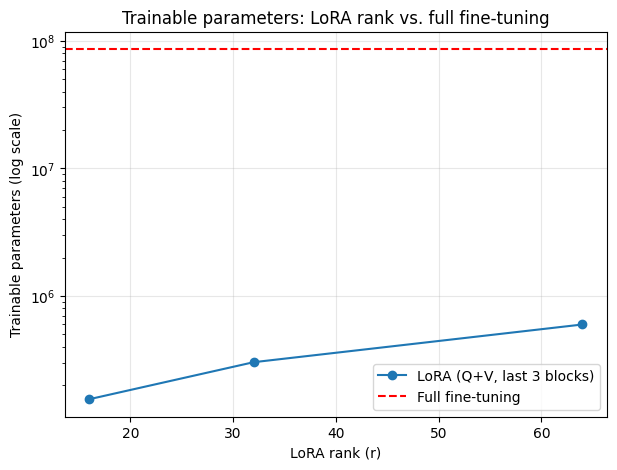

In [23]:
ranks = CONFIG["lora_ranks"]
lora_trainable = [lora_rank_results[r]["trainable_params"] for r in ranks]

plt.figure(figsize=(7, 5))
plt.plot(ranks, lora_trainable, marker="o", label="LoRA (Q+V, last 3 blocks)")
plt.axhline(full_ft_result["trainable_params"], color="red", linestyle="--",
            label="Full fine-tuning")
plt.yscale("log")
plt.xlabel("LoRA rank (r)")
plt.ylabel("Trainable parameters (log scale)")
plt.title("Trainable parameters: LoRA rank vs. full fine-tuning")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Plot 2 — Accuracy and F1 vs. rank

Shows whether increasing the rank actually buys you meaningfully better accuracy, or
whether it plateaus quickly (a common finding with LoRA — small ranks often get you most
of the way there).


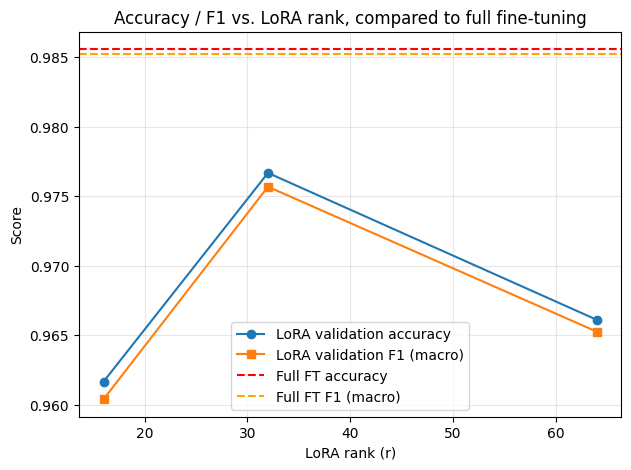

In [24]:
lora_acc = [lora_rank_results[r]["final_val_acc"] for r in ranks]
lora_f1 = [lora_rank_results[r]["final_val_f1"] for r in ranks]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(ranks, lora_acc, marker="o", label="LoRA validation accuracy")
ax.plot(ranks, lora_f1, marker="s", label="LoRA validation F1 (macro)")
ax.axhline(full_ft_result["final_val_acc"], color="red", linestyle="--",
           label="Full FT accuracy")
ax.axhline(full_ft_result["final_val_f1"], color="orange", linestyle="--",
           label="Full FT F1 (macro)")
ax.set_xlabel("LoRA rank (r)")
ax.set_ylabel("Score")
ax.set_title("Accuracy / F1 vs. LoRA rank, compared to full fine-tuning")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


### Plot 3 — Training loss curves, every experiment on one chart

This is the direct "training loss" and "validation loss" comparison the assignment asks
for, for every configuration at once.


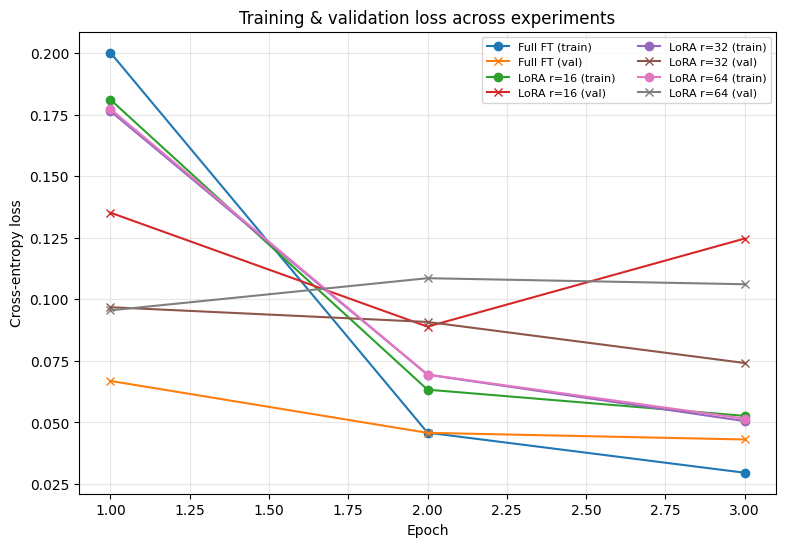

In [25]:
plt.figure(figsize=(9, 6))

def plot_history(history, label, linestyle="-"):
    epochs_axis = range(1, len(history["train_loss"]) + 1)
    plt.plot(epochs_axis, history["train_loss"], linestyle, marker="o", label=f"{label} (train)")
    plt.plot(epochs_axis, history["val_loss"], linestyle, marker="x", label=f"{label} (val)")

plot_history(full_ft_result["history"], "Full FT")
for r in ranks:
    plot_history(lora_rank_results[r]["history"], f"LoRA r={r}")

plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Training & validation loss across experiments")
plt.legend(fontsize=8, ncol=2)
plt.grid(True, alpha=0.3)
plt.show()


### Plot 4 — Training time and peak GPU memory

Directly compares the *cost* side of the trade-off: how much faster/lighter is LoRA in
practice, on this GPU, for this dataset?


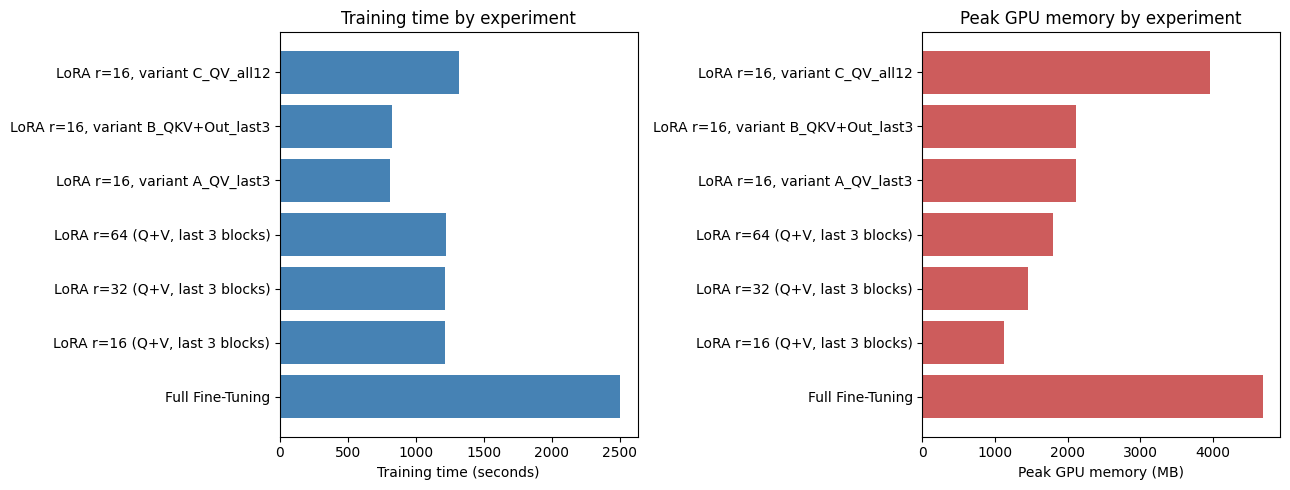

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labels = summary_df["experiment"].tolist()
times = summary_df["train_time_sec"].tolist()
mems = summary_df["peak_gpu_mem_mb"].tolist()

axes[0].barh(labels, times, color="steelblue")
axes[0].set_xlabel("Training time (seconds)")
axes[0].set_title("Training time by experiment")

axes[1].barh(labels, mems, color="indianred")
axes[1].set_xlabel("Peak GPU memory (MB)")
axes[1].set_title("Peak GPU memory by experiment")

plt.tight_layout()
plt.show()


## 11. Turning this into your report

The `summary_df` table above already contains every number the assignment's objective
list asks you to report:

- Number of trainable parameters → `trainable_params`, `trainable_pct` columns
- Training loss / validation loss → Plot 3 (and full curves are in each `result["history"]`)
- Accuracy / F1-score → `val_accuracy`, `val_f1_macro` columns
- GPU memory → `peak_gpu_mem_mb` column, Plot 4
- Training time → `train_time_sec` column, Plot 4
- Model size → `model_size_mb` column
- Effect of different LoRA ranks → Experiment B, Plots 1 & 2
- Effect of different target layers → Experiment C

**Things worth writing about in your discussion section**, based on what you'll typically
observe running this notebook:

1. How close LoRA gets to full fine-tuning accuracy while training a tiny fraction of the
   parameters — and at what rank the gap becomes negligible.
2. Whether GPU memory and training time actually drop for LoRA in your run, and by how
   much (the theoretical savings can be partly hidden by data loading time on a small
   64×64-pixel dataset like this one).
3. Whether spreading LoRA across all 12 blocks (variant C) beats concentrating it in the
   last 3 blocks (variant A) at the same rank, and whether adding Key + the attention
   output projection (variant B) helps more than more blocks do.
4. Anything surprising: e.g. a rank where accuracy stops improving, or a variant that
   trains fewer parameters than another but still matches its accuracy.

**A note on the epoch counts used above:** `CONFIG["epochs_full_ft"]`,
`CONFIG["epochs_lora"]`, and `CONFIG["epochs_target_layers"]` are deliberately kept small
(2–3) so the whole notebook can run within a typical Kaggle GPU session. If your GPU time
budget allows it, increasing these (and setting `SUBSET_FRACTION = 1.0`, which it already
is) will generally improve every model's final accuracy and make the comparison more
representative of each method's true ceiling — just re-run from section 6 onward.
